In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Caminho exato do arquivo no meu computador (ajuste conforme necessário)
caminho_arquivo = r"C:\Users\luiso\Downloads\Projeto SCTECH\base varejo.csv"

# Carregando a base de dados localmente
df = pd.read_csv(caminho_arquivo, sep=';')


# 1. Ver as primeiras linhas
print("=== Análise das primeiras 5 linhas ===")
print(df.head())

# 2. Estrutura da base (Tipo de dado de cada coluna e quantidade de não-nulos)
print("\n=== Estrutura da base ===")
df.info()

=== Análise das primeiras 5 linhas ===
         DATA  CO_ID  CL_ID CL_GENERO  CL_EC  CL_FHL CL_SEG  PR_ID     PR_CAT  \
0  01/02/2019   1000    534         M      4       1      C     67    BEBIDAS   
1  01/02/2019   1000    534         M      4       1      C     70    BEBIDAS   
2  01/02/2019   1000    534         M      4       1      C    178    HIGIENE   
3  01/02/2019   1000    534         M      4       1      C      4  ALIMENTOS   
4  01/02/2019   1000    534         M      4       1      C    175    LIMPEZA   

                PR_NOME  Unnamed: 10  Unnamed: 11  Unnamed: 12  Unnamed: 13  
0  REFRIGERANTE GUARANA          NaN          NaN          NaN          NaN  
1   REFRIGERANTE OUTROS          NaN          NaN          NaN          NaN  
2       LENCO UMEDECIDO          NaN          NaN          NaN          NaN  
3               ABACAXI          NaN          NaN          NaN          NaN  
4     LIMPADOR MULTIUSO          NaN          NaN          NaN          NaN  

=== E

Análise do Módulo 1

1. Colunas "nulas" (Unnamed: 10 a Unnamed: 13)
Usando o df.info() verifiquei que essas 4 colunas possuem (0 non-null), ou seja, estão 100% vazias. Além disso, também não as encontrei no arquivo .PDF oficial do banco de dados.

Será necessário excluí-las para não sujar nossa base e liberar memória

2. O tipo de dado da coluna DATA
Identifiquei a coluna DATA como string (texto)

Para fazer cálculos de tempo (como agrupar por mês ou ano), precisaremos converter para o tipo datetime



In [3]:
# === Módulo 2 e 3: Limpeza e Transformação dos Dados ===

print("\n=== Iniciando Limpeza de Dados ===")

# 1. Removendo as colunas "Nulas" (Unnamed)
# O dropna(axis=1, how='all') apaga qualquer coluna que esteja 100% vazia
df = df.dropna(axis=1, how='all')

# 2. Convertendo a coluna DATA para datetime
# O parâmetro format="%d/%m/%Y" garante que o pandas leia dia/mês/ano corretamente
df['DATA'] = pd.to_datetime(df['DATA'], format="%d/%m/%Y", errors='coerce')

# 3. Tratamento de Valores Nulos na Categoria, incluindo a categoria 'Sem Categoria'
df['PR_CAT'] = df['PR_CAT'].fillna('Sem Categoria')

# 4. Verificando e removendo duplicatas
duplicadas_antes = df.duplicated().sum()
print(f"Total de duplicatas encontradas: {duplicadas_antes}")

# Remove as duplicatas mantendo a primeira ocorrência
df = df.drop_duplicates()

# === Verificação pós-limpeza ===
print("\n=== Estrutura da base após a limpeza ===")
df.info()


=== Iniciando Limpeza de Dados ===
Total de duplicatas encontradas: 96553

=== Estrutura da base após a limpeza ===
<class 'pandas.DataFrame'>
Index: 733447 entries, 0 to 829999
Data columns (total 10 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   DATA       733447 non-null  datetime64[us]
 1   CO_ID      733447 non-null  int64         
 2   CL_ID      733447 non-null  int64         
 3   CL_GENERO  733447 non-null  str           
 4   CL_EC      733447 non-null  int64         
 5   CL_FHL     733447 non-null  int64         
 6   CL_SEG     733447 non-null  str           
 7   PR_ID      733447 non-null  int64         
 8   PR_CAT     733447 non-null  str           
 9   PR_NOME    733447 non-null  str           
dtypes: datetime64[us](1), int64(5), str(4)
memory usage: 61.6 MB


Análise do Módulo 2 e 3

1. Foram identificados e removidos 96.553 registros duplicados. Se esses dados não fossem limpos, a empresa calcularia seu volume de vendas com uma distorção de mais de 11%!

In [ ]:
# Módulo 4 e 5: Enriquecimento e Estatística Descritiva

print("=== Módulo 4: Enriquecimento e Estatística Descritiva ===\n")

# 1. Enriquecimento de Dados: Criando a coluna "Estado_Civil" a partir da coluna "CL_EC"
# Tradução da coluna CL_EC baseando-se no arquivo .PDF da base de dados para facilitar o entendimento
dict_estado_civil = {1: 'Casado(a)', 2: 'Divorciado(a)', 3: 'Separado(a)', 4: 'Solteiro(a)', 5: 'Viúvo(a)'}

# Criando uma nova coluna "Estado_Civil" com os rótulos legíveis
df['Estado_Civil'] = df['CL_EC'].map(dict_estado_civil)  

# Extraindo informações de tempo para análises de tendência
df['Ano'] = df['DATA'].dt.year

# 2. Estatística Descritiva: Analisando a coluna "Número de Filhos" (CL_FHL)
filhos = df['CL_FHL']
print("--- Estatísticas: Número de Filhos (CL_FHL) ---")
print(f"Contagem (Total de registros): {filhos.count()}")
print(f"Média                        : {filhos.mean():.2f}")
print(f"Mediana                      : {filhos.median():.2f}")
print(f"Desvio Padrão                : {filhos.std():.2f}")
print(f"Moda (Mais comum)            : {filhos.mode()}")
print(f"Mínimo                       : {filhos.min()}")
print(f"Máximo                       : {filhos.max()}")

print("\n=== Módulo 5: Padrões de Agrupamento e Insights ===\n")

# 3. Agrupamento e Insights: Analisando o volume de transações por perfil socioeconômico, gênero e estado civil
# Agrupamento 1: Qual perfil socioeconômico e gênero tem mais volume de transações?
# Como não temos o "Valor da Compra", contamos o número da nota fiscal (CO_ID)
pivot_perfil = pd.pivot_table(df, values='CO_ID', index='CL_SEG', columns='CL_GENERO', aggfunc='count', fill_value=0)
print("--- Volume de Transações: Segmento Econômico vs Gênero ---")
print(pivot_perfil)

# Agrupamento 2: O Estado Civil afeta a categoria de produtos comprada?
pivot_categoria = pd.pivot_table(df, values='CO_ID', index='PR_CAT', columns='Estado_Civil', aggfunc='count', fill_value=0)
print("\n--- Volume de Transações: Categoria vs Estado Civil ---")
print(pivot_categoria)


=== Módulo 4: Enriquecimento e Estatística Descritiva ===

--- Estatísticas: Número de Filhos (CL_FHL) ---
Contagem (Total de registros): 733447
Média                        : 1.15
Mediana                      : 0.00
Desvio Padrão                : 1.42
Moda (Mais comum)            : 0    0
Name: CL_FHL, dtype: int64
Mínimo                       : 0
Máximo                       : 4

=== Módulo 5: Padrões de Agrupamento e Insights ===

--- Volume de Transações: Segmento Econômico vs Gênero ---
CL_GENERO       F       M
CL_SEG                   
A           28898   30779
B          233644  234861
C          119885   85380

--- Volume de Transações: Categoria vs Estado Civil ---
Estado_Civil  Casado(a)  Divorciado(a)  Separado(a)  Solteiro(a)  Viúvo(a)
PR_CAT                                                                    
#N/D                766            803          810          776        73
ACESSORIOS         2993           3006         3411         3115       346
ALIMENTOS       

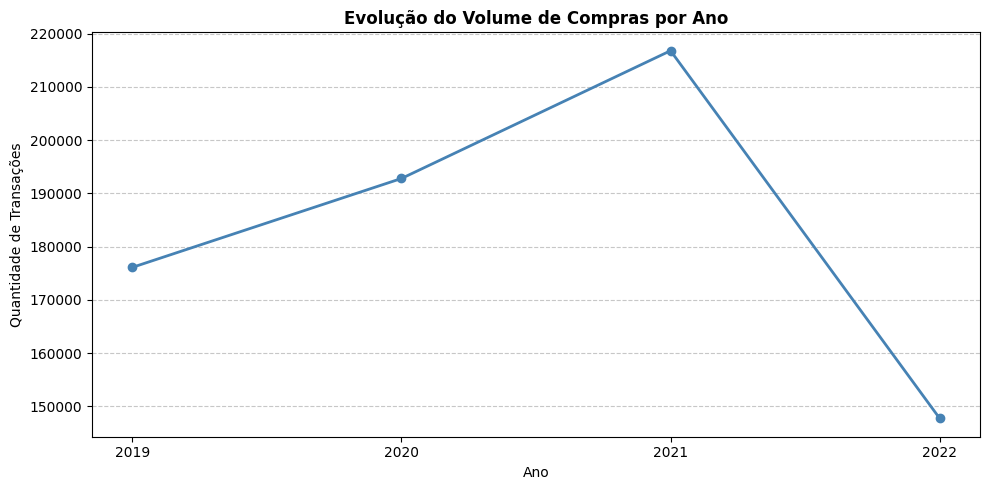

In [5]:
# VISUALIZAÇÃO GRÁFICA
vendas_ano = df.groupby('Ano')['CO_ID'].count().reset_index()

plt.figure(figsize=(10, 5))
plt.plot(vendas_ano['Ano'], vendas_ano['CO_ID'], marker='o', color='steelblue', linewidth=2)
plt.title("Evolução do Volume de Compras por Ano", fontweight='bold')
plt.xlabel("Ano")
plt.ylabel("Quantidade de Transações")
# Ajustando as marcações do eixo X para mostrar apenas os anos inteiros presentes na base
plt.xticks(vendas_ano['Ano'].astype(int))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Principais Insights e Descobertas:

A Assimetria no Número de Filhos: A análise estatística da coluna CL_FHL revelou que a grande maioria dos clientes não possui filhos (Moda e Mediana iguais a 0). No entanto, a média de 1.15 indica que há um grupo menor de clientes com muitos filhos (máximo de 4) que "puxa" a média para cima.

A Força da Classe Média (Segmento B): O cruzamento de Segmento vs. Gênero mostrou que o Segmento B é o motor do supermercado, totalizando mais de 468 mil transações. O volume da Classe B é quase 8 vezes maior que o da Classe A.

Comportamento Feminino na Classe C: Enquanto nos Segmentos A e B os homens e mulheres têm volumes de compra muito semelhantes, na Classe C as mulheres (119.885 transações) compram substancialmente mais do que os homens (85.380 transações).

Alimentos Dominam: Independentemente do estado civil, a categoria "ALIMENTOS" é a líder disparada de vendas (mais de 472 mil itens no total), representando o coração, seguida por "HIGIENE" e "LIMPEZA".

Problema Remanescente na Base de Dados: O agrupamento por categoria revelou a existência de 3.228 registros com a nomenclatura #N/D. Isso indica um erro na origem, provavelmente valor ausente foi salvo como texto (string), burlando o filtro isnull() do Python. Essa sujeira precisaria de um tratamento adicional.

In [6]:
# Limpeza (Tratamento de Sujeira Oculta)

print("\n=== Limpeza (Tratamento de Sujeira Oculta) ===")

# 1. Aplicando a correção no problema remanescente identificado
df.loc[df['PR_CAT'] == '#N/D', 'PR_CAT'] = 'Sem Categoria'
print("Sujeira '#N/D' identificada e substituída com sucesso por 'Sem Categoria'.")

# 2. Rodando o agrupamento novamente para provar a correção
pivot_categoria_corrigida = pd.pivot_table(df, values='CO_ID', index='PR_CAT', columns='Estado_Civil', aggfunc='count', fill_value=0)

print("\n--- Volume de Transações: Categoria vs Estado Civil (CORRIGIDO) ---")
print(pivot_categoria_corrigida)


=== Limpeza (Tratamento de Sujeira Oculta) ===
Sujeira '#N/D' identificada e substituída com sucesso por 'Sem Categoria'.

--- Volume de Transações: Categoria vs Estado Civil (CORRIGIDO) ---
Estado_Civil   Casado(a)  Divorciado(a)  Separado(a)  Solteiro(a)  Viúvo(a)
PR_CAT                                                                     
ACESSORIOS          2993           3006         3411         3115       346
ALIMENTOS          90143          90379        98817        93872     10986
BEBIDAS             8969           9109         9805         9254      1127
HIGIENE            32287          32172        35615        33770      3858
LIMPEZA            30088          30121        33218        31509      3696
PET                 6764           6693         7372         6910       814
Sem Categoria        766            803          810          776        73


A linha #N/D desapareceu e os números exatos dela (766 casados, 803 divorciados, etc.) foram transferidos para a nova linha Sem Categoria.

Esse resultado mostrou que o comando fillna('Sem Categoria') que usei no Módulo 2 não havia alterado nenhuma linha, visto que o arquivo não deixou as células vazias (que o Python leria como NaN). Em vez disso, o sistema preencheu os campos vazios com o texto (#N/D) - Erro comum.

In [ ]:
print("\n=== Explorações de Negócio (Possibilidades) ===")

# 1. SAZONALIDADE: Agrupando pelo número (ID) e mapeando o texto no final
df['DATA'] = pd.to_datetime(df['DATA'], format="%d/%m/%Y", errors='coerce')

# Extraí apenas o "ID" numérico do mês (1, 2, 3...)
df['Mês_ID'] = df['DATA'].dt.month

# Assim o agrupamento usando o número já fica naturalmente na ordem cronológica
vendas_mes = df.groupby('Mês_ID')['CO_ID'].count().reset_index()

# Mapeei os IDs numéricos para os nomes legíveis
meses_pt = {1: 'Jan', 2: 'Fev', 3: 'Mar', 4: 'Abr', 5: 'Mai', 6: 'Jun', 
            7: 'Jul', 8: 'Ago', 9: 'Set', 10: 'Out', 11: 'Nov', 12: 'Dez'}
vendas_mes['Mês'] = vendas_mes['Mês_ID'].map(meses_pt)

# Selecionei apenas as colunas úteis (nome do mês e total) e renomeei
vendas_mes = vendas_mes[['Mês', 'CO_ID']]
vendas_mes.rename(columns={'CO_ID': 'Qtd_Transações'}, inplace=True)

# Formatando os números com separador de milhar
vendas_mes['Qtd_Transações'] = vendas_mes['Qtd_Transações'].apply(lambda x: f"{x:,.0f}")

print("\n--- Volume de Transações por Mês ---")
print(vendas_mes.to_string(index=False))


# 2. Classificando tipo de famílias por qdt de flilhos, usando np.select
condicoes = [
    df['CL_FHL'] == 0,          # Sem filhos
    df['CL_FHL'].isin([1, 2]),  # Família Pequena (1 ou 2 filhos)
    df['CL_FHL'] >= 3           # Família Grande (3 ou mais filhos) 
]
categorias = ['Sem Filhos', 'Família Pequena', 'Família Grande']
df['Tamanho_Familia'] = np.select(condicoes, categorias, default='Outros')

print("\n--- Distribuição de Vendas por Tamanho da Família ---")
contagens_familia = df['Tamanho_Familia'].value_counts()
for categoria, qtd in contagens_familia.items():
    print(f"  {categoria:<16}: {qtd:>8,.0f} transações")


# 3. Enriquecimento de Dados com Merge (Usando Pesos Relativos em vez de R$)

# Usei valores fictícios para os pesos, mas a ideia é que eles representem a importância relativa de cada categoria na receita total
pesos_ficticios = pd.DataFrame({
    'PR_CAT': ['ALIMENTOS', 'BEBIDAS', 'HIGIENE', 'LIMPEZA', 'PET', 'ACESSORIOS', 'Sem Categoria'],
    'Peso_Receita': [15.50, 8.90, 12.30, 22.00, 35.00, 45.00, 10.00]
})

df = pd.merge(df, pesos_ficticios, on='PR_CAT', how='left')

# Calculei a base total (100%)
receita_total_pontos = df['Peso_Receita'].sum()


# 4. RANKING: Top 5 Produtos (Representatividade % na Receita Estimada)

top_produtos = df.groupby('PR_NOME')['Peso_Receita'].sum().sort_values(ascending=False).head(5)

print("\n--- Top 5 Produtos (Representatividade % na Receita) ---")
# O cálculo agora divide o valor do produto pelo total geral e multiplica por 100 para virar %
for produto, valor_pontos in top_produtos.items():
    percentual = (valor_pontos / receita_total_pontos) * 100
    print(f"  {produto:<30} {percentual:>6.2f}%")


=== Explorações de Negócio (Possibilidades) ===

--- Volume de Transações por Mês ---
Mês Qtd_Transações
Jan         74,121
Fev         67,130
Mar         56,929
Abr         59,220
Mai         72,799
Jun         59,848
Jul         60,936
Ago         58,022
Set         60,687
Out         65,350
Nov         36,075
Dez         62,330

--- Distribuição de Vendas por Tamanho da Família ---
  Sem Filhos      :  384,986 transações
  Família Pequena :  185,013 transações
  Família Grande  :  163,448 transações

--- Top 5 Produtos (Representatividade % na Receita) ---
  CHUPETA                          2.34%
  MORDEDOR                         2.32%
  RACAO SECA PARA CAES             1.81%
  RACAO UMIDA PARA CAES            1.79%
  RACAO SECA PARA GATOS            1.79%


Análise Temporal: A extração dos meses revelou que Janeiro e Maio são os meses de pico (mais de 72 mil transações), enquanto Novembro sofre uma queda drástica (apenas 36 mil transações), indicando necessidade de campanhas de marketing direcionadas para este mês.

A Força do Ticket PET/Bebê (Representatividade %): Como a base original não possuía os preços dos itens, simulei uma tabela auxiliar de "pesos de receita" por categoria e enriqueci a base via pd.merge(). 

Para garantir responsabilidade com a informação, os resultados foram exibidos em proporção percentual em vez de valores absolutos. 

A análise revelou que os 5 produtos que mais tracionam a receita são Nichos Específicos (Chupetas, Mordedores e Rações), correspondendo juntos a quase 10% de todo o share financeiro da rede, mesmo com "Alimentos" liderando no volume bruto.



=== Gerando Dashboard Gráfico ===


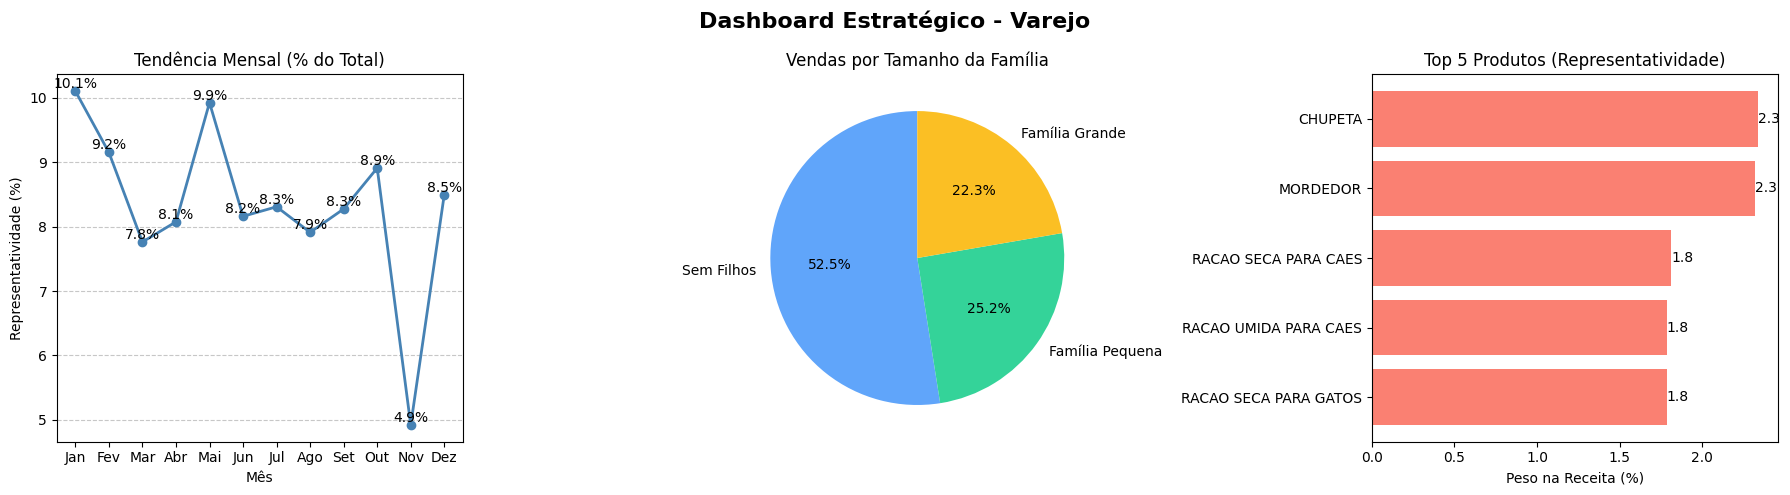

In [ ]:
print("\n=== Gerando Dashboard Gráfico ===")

# Preparação dos dados para o dashboard

# Garantir que a DATA esteja no formato datetime
df['DATA'] = pd.to_datetime(df['DATA'], errors='coerce')

# Vendas por mês
vendas_brutas_mes = (df.groupby(df['DATA'].dt.month)['CO_ID'].count())

# Converter para percentual
total_vendas = vendas_brutas_mes.sum()
vendas_percentual_mes = (vendas_brutas_mes / total_vendas) * 100

# Nomes dos meses
meses_pt = {
    1: 'Jan',
    2: 'Fev',
    3: 'Mar',
    4: 'Abr',
    5: 'Mai',
    6: 'Jun',
    7: 'Jul',
    8: 'Ago',
    9: 'Set',
    10: 'Out',
    11: 'Nov',
    12: 'Dez'
}

meses_labels = [meses_pt[i]for i in vendas_percentual_mes.index]

# Criação do dashboard com 3 gráficos
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

fig.suptitle('Dashboard Estratégico - Varejo', fontsize=16, fontweight='bold')


# 1. Tendência Mensal: Representatividade percentual de cada mês no total de vendas
axes[0].plot(meses_labels, vendas_percentual_mes.values, marker='o', color='steelblue', linewidth=2)

axes[0].set_title('Tendência Mensal (% do Total)')
axes[0].set_xlabel('Mês')
axes[0].set_ylabel('Representatividade (%)')

axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Adiciona valores nos pontos
for x, y in zip(meses_labels, vendas_percentual_mes.values):
    axes[0].text(x, y, f'{y:.1f}%', ha='center', va='bottom')


# 2. Tamanho da Família: Distribuição percentual de vendas por tipo de família
contagens = df['Tamanho_Familia'].value_counts()

cores_pizza = ['#60a5fa', '#34d399', '#fbbf24', '#f87171']

axes[1].pie(contagens.values, labels=contagens.index, autopct='%1.1f%%', colors=cores_pizza, startangle=90)

axes[1].set_title('Vendas por Tamanho da Família')


# 3. TOP 5 Produtos (Representatividade % na Receita Estimada)
top_prod_grafico = (df.groupby('PR_NOME')['Peso_Receita'].sum().sort_values(ascending=True).tail(5) / receita_total_pontos) * 100

axes[2].barh(top_prod_grafico.index, top_prod_grafico.values, color='salmon')

axes[2].set_title('Top 5 Produtos (Representatividade)')

axes[2].set_xlabel('Peso na Receita (%)')

# Adiciona valores nas barras
for i, valor in enumerate(top_prod_grafico.values):
    axes[2].text(valor, i, f'{valor:.1f}', va='center')


plt.tight_layout()

plt.show()

In [9]:
# Gerando o arquivo CSV da base limpa
# Salva o DataFrame tratado em um arquivo CSV, ignorando o índice numérico
df.to_csv('df_limpo.csv', index=False, sep=';', encoding='utf-8-sig')

print("\n Arquivo 'df_limpo.csv' gerado com sucesso na pasta atual!")


 Arquivo 'df_limpo.csv' gerado com sucesso na pasta atual!
